# 🌳 Algoritmo C4.5 / C5.0 — Árbol de Decisión
**Tarea 1 – Investigación en Grupo | Módulo: Algoritmos de Machine Learning**

---

## 1. Descripción del Algoritmo

**C4.5** es un algoritmo de aprendizaje supervisado para la construcción de árboles de decisión, desarrollado por **Ross Quinlan** en 1993 como una extensión mejorada de su algoritmo previo ID3. Su sucesor comercial, **C5.0**, introduce mejoras en velocidad, uso de memoria y precisión.

El algoritmo construye un árbol de decisión a partir de datos de entrenamiento etiquetados, utilizando el concepto de **Ganancia de Información** y el **Ratio de Ganancia** (Information Gain Ratio) para seleccionar el atributo más relevante en cada nodo de división. A diferencia de ID3, C4.5 puede manejar:
- Atributos continuos (numéricos)
- Valores faltantes (missing values)
- Poda del árbol para evitar sobreajuste (pruning)
- Conversión del árbol en reglas IF-THEN legibles

## 2. Publicación que Propuso el Algoritmo (BibTeX y Referencias)

### BibTeX Original — C4.5
```bibtex
@book{quinlan1993c4,
  title     = {C4.5: Programs for Machine Learning},
  author    = {Quinlan, J. Ross},
  year      = {1993},
  publisher = {Morgan Kaufmann Publishers},
  address   = {San Mateo, California},
  isbn      = {1-55860-238-0}
}
```

### BibTeX — C5.0 / Ver. mejorada
```bibtex
@article{quinlan1996improved,
  title   = {Improved use of continuous attributes in C4.5},
  author  = {Quinlan, J. Ross},
  journal = {Journal of Artificial Intelligence Research},
  volume  = {4},
  pages   = {77--90},
  year    = {1996},
  publisher = {AI Access Foundation}
}
```

### Referencias APA
- Quinlan, J. R. (1993). *C4.5: Programs for Machine Learning*. Morgan Kaufmann Publishers.
- Quinlan, J. R. (1996). Improved use of continuous attributes in C4.5. *Journal of Artificial Intelligence Research, 4*, 77–90.

## 3. Tipo de Modelo

| Dimensión | Clasificación |
|---|---|
| **Método de Aprendizaje** | Aprendizaje Supervisado — Clasificación (también puede hacer regresión) |
| **Por Parámetros** | No Paramétrico — no asume ninguna distribución estadística de los datos |
| **Datos de Aprendizaje** | Offline / Batch — se entrena con todo el conjunto de datos a la vez |
| **Resultado del Entrenamiento** | Basado en Modelo — genera un árbol de decisión (estructura matemática/lógica) |

## 4. Algoritmo de Entrenamiento

C4.5 utiliza el criterio de **Ratio de Ganancia de Información** para dividir los nodos:

### Fórmulas clave:

**Entropía:**
$$H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

**Ganancia de Información:**
$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

**Ratio de Ganancia (mejora sobre ID3):**
$$GainRatio(S, A) = \frac{IG(S, A)}{SplitInfo(S, A)}$$

### Proceso:
1. Calcular el Ratio de Ganancia para cada atributo
2. Seleccionar el atributo con mayor Ratio de Ganancia como nodo raíz/nodo de división
3. Crear ramas para cada valor del atributo seleccionado
4. Repetir recursivamente hasta alcanzar nodos puros o criterio de parada
5. Aplicar **poda (pruning)** para reducir el sobreajuste

## 5. Tipos de Entrada

- **Atributos categóricos** (ej: color, tipo, categoría)
- **Atributos numéricos/continuos** (ej: edad, temperatura, precio) — C4.5 los discretiza automáticamente
- **Valores faltantes (NaN)** — C4.5 los maneja distribuyendo probabilísticamente
- **Variable objetivo (target):** categórica (clasificación) o numérica (regresión)
- **Formato de entrada:** tabla/dataset con filas=muestras, columnas=características

## 6. Casos de Uso

| Área | Aplicación |
|---|---|
| 🏥 Medicina | Diagnóstico de enfermedades (clasificar si un paciente tiene o no una condición) |
| 💳 Finanzas | Detección de fraude, aprobación de créditos |
| 📧 Marketing | Segmentación de clientes, predicción de churn |
| 🌿 Biología | Clasificación de especies de plantas o animales |
| 🎓 Educación | Predicción de rendimiento académico |
| 🌤️ Meteorología | Clasificación de condiciones climáticas |

## 7. Supuestos y Restricciones

### Supuestos:
- Los datos de entrenamiento son representativos de la distribución real
- Los atributos tienen poder discriminativo sobre la variable objetivo
- Se asume que las relaciones entre variables pueden representarse jerárquicamente

### Restricciones:
- Puede generar árboles muy profundos con datos ruidosos (sobreajuste), aunque la poda lo mitiga
- Sesgo hacia atributos con muchos valores únicos (aunque el Ratio de Ganancia lo corrige vs ID3)
- Puede ser inestable: pequeños cambios en los datos pueden cambiar la estructura del árbol
- No es ideal para relaciones lineales simples (la regresión lineal sería más eficiente en esos casos)
- Complejidad computacional puede crecer con datasets muy grandes

## 8. Source Code — Implementación en Python

Usaremos `scikit-learn` que implementa una versión optimizada basada en C4.5/CART (el clasificador más cercano disponible en Python).

In [11]:
# Instalación (solo necesario en Colab si no está disponible)
# !pip install scikit-learn matplotlib pandas

In [1]:
# ============================================================
# PASO 1: Importar librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.datasets import load_iris
import seaborn as sns

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [2]:
# ============================================================
# PASO 2: Cargar dataset (Iris — clásico para clasificación)
# ============================================================
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')

print('Shape del dataset:', X.shape)
print('Clases:', iris.target_names)
X.head()

Shape del dataset: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# ============================================================
# PASO 3: División Train / Test
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 105 muestras
Test:  45 muestras


In [4]:
# ============================================================
# PASO 4: Entrenar el modelo C4.5 / Decision Tree
# criterion='entropy' replica el comportamiento de C4.5
# ============================================================
modelo_c45 = DecisionTreeClassifier(
    criterion='entropy',   # C4.5 usa ganancia de información (entropía)
    max_depth=5,           # Limitar profundidad para evitar sobreajuste
    min_samples_split=5,
    random_state=42
)

modelo_c45.fit(X_train, y_train)
print('Modelo entrenado con éxito')

Modelo entrenado con éxito


In [5]:
# ============================================================
# PASO 5: Evaluación del modelo
# ============================================================
y_pred = modelo_c45.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 88.89 %

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.81      0.87      0.84        15
   virginica       0.86      0.80      0.83        15

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45



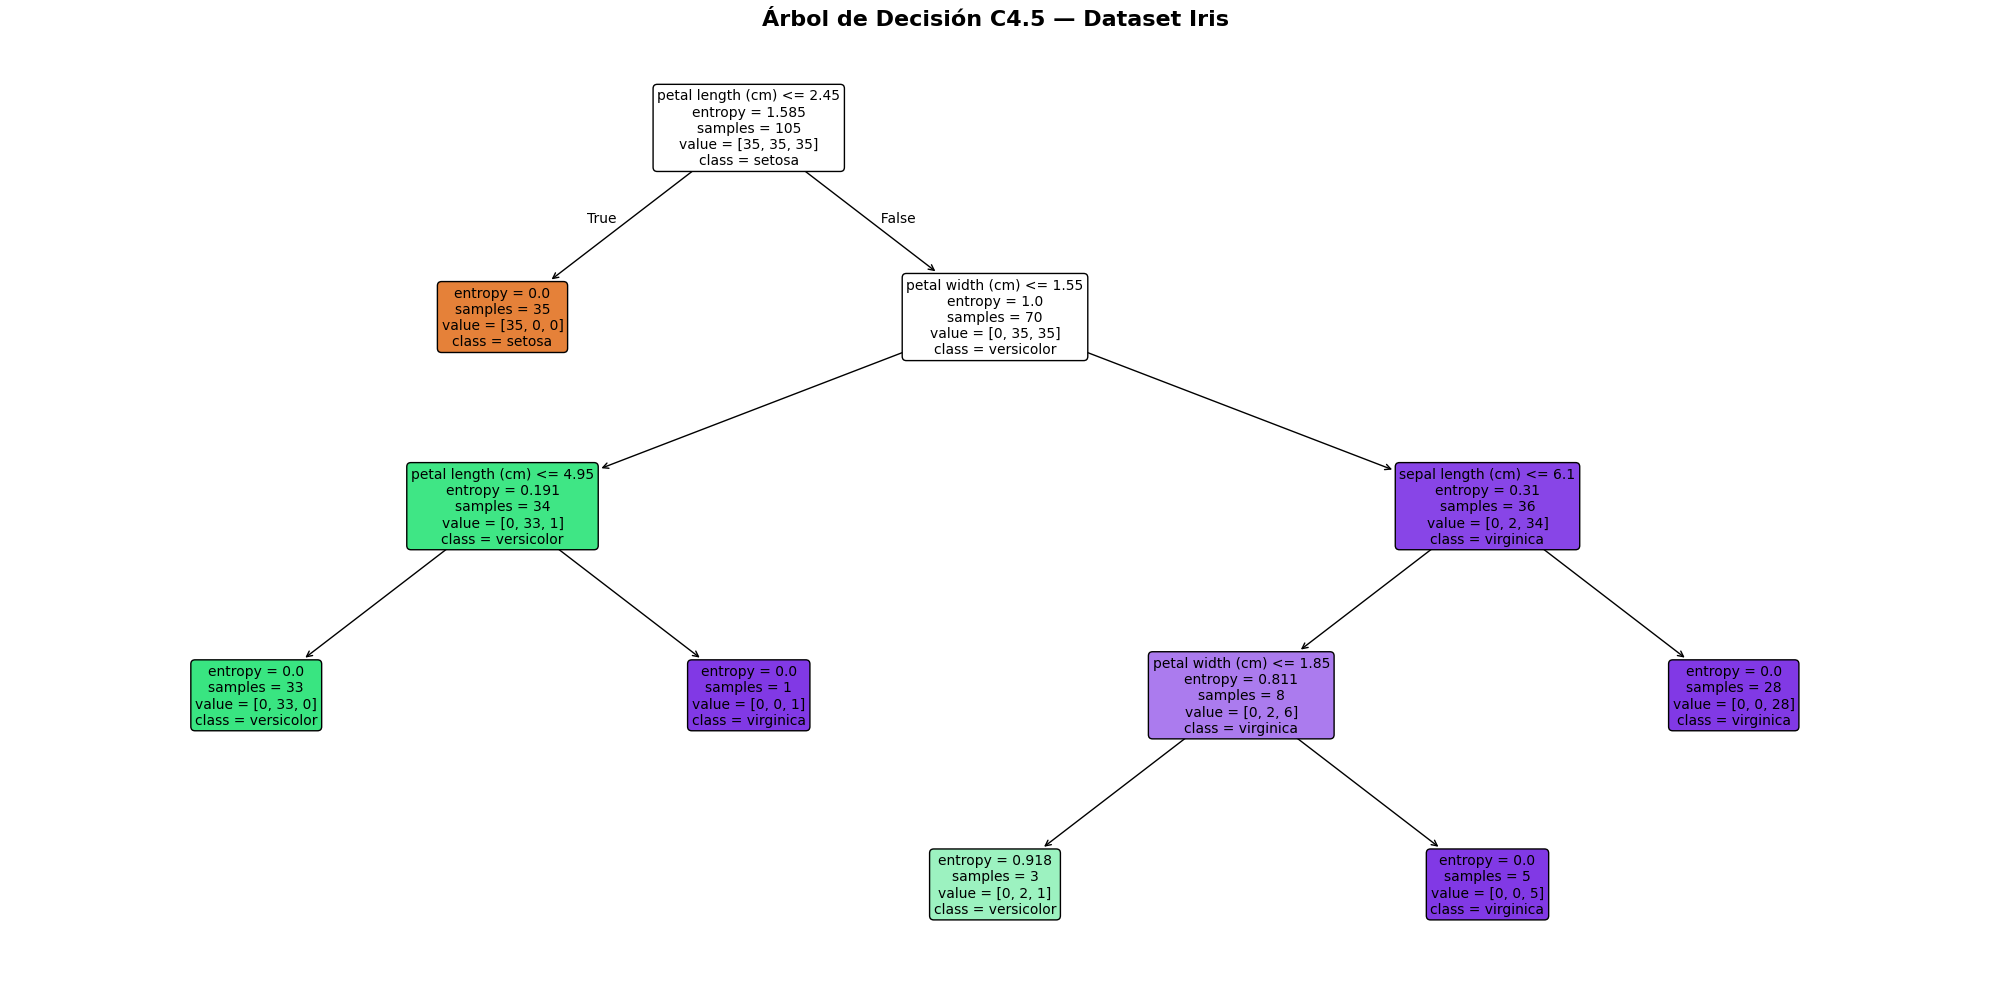

In [6]:
# ============================================================
# PASO 6: Visualizar el Árbol de Decisión
# ============================================================
plt.figure(figsize=(20, 10))
plot_tree(
    modelo_c45,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión C4.5 — Dataset Iris', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

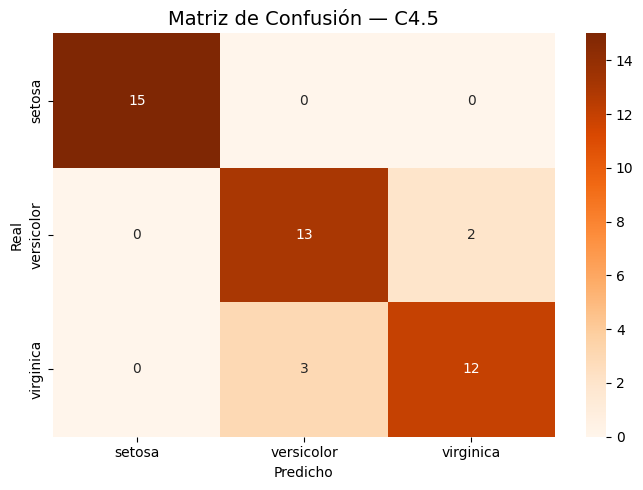

In [7]:
# ============================================================
# PASO 7: Matriz de Confusión
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Matriz de Confusión — C4.5', fontsize=14)
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# PASO 8: Ver las reglas IF-THEN generadas por el árbol
# ============================================================
reglas = export_text(modelo_c45, feature_names=list(iris.feature_names))
print('Reglas IF-THEN del árbol C4.5:')
print(reglas)

Reglas IF-THEN del árbol C4.5:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- sepal length (cm) <= 6.10
|   |   |   |--- petal width (cm) <= 1.85
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.85
|   |   |   |   |--- class: 2
|   |   |--- sepal length (cm) >  6.10
|   |   |   |--- class: 2



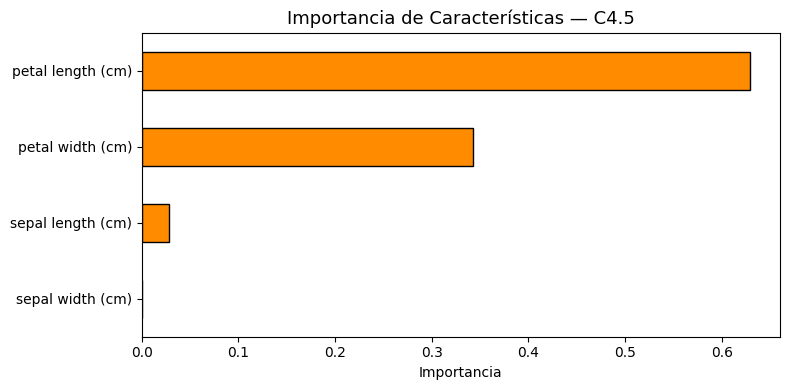

In [9]:
# ============================================================
# PASO 9: Importancia de Características
# ============================================================
importancias = pd.Series(
    modelo_c45.feature_importances_,
    index=iris.feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Importancia de Características — C4.5', fontsize=13)
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# PASO 10: Predicción con nuevos datos
# ============================================================
# Ejemplo: nueva flor con medidas [sépalo largo, sépalo ancho, pétalo largo, pétalo ancho]
nueva_muestra = np.array([[5.1, 3.5, 1.4, 0.2]])  # Probablemente setosa

prediccion = modelo_c45.predict(nueva_muestra)
probabilidad = modelo_c45.predict_proba(nueva_muestra)

print(f'Predicción: {iris.target_names[prediccion[0]]}')
print(f'Probabilidades por clase:')
for nombre, prob in zip(iris.target_names, probabilidad[0]):
    print(f'   {nombre}: {prob:.2%}')

Predicción: setosa
Probabilidades por clase:
   setosa: 100.00%
   versicolor: 0.00%
   virginica: 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## 9. Comparación C4.5 vs C5.0

| Característica | C4.5 | C5.0 |
|---|---|---|
| Velocidad | Moderada | Mucho más rápido |
| Uso de memoria | Mayor | Menor |
| Precisión | Buena | Mejor (generalmente) |
| Boosting | No | Sí (soporta boosting) |
| Licencia | Open Source | Comercial (RuleQuest) |
| Python equivalente | `criterion='entropy'` | No disponible directamente |

> En Python/scikit-learn se usa `DecisionTreeClassifier(criterion='entropy')` como aproximación a C4.5.

---
# Ejemplo Práctico — C5.0

C5.0 es la versión comercial y mejorada de C4.5, desarrollada también por **Ross Quinlan**. En Python no existe una librería oficial, pero podemos replicar su comportamiento:

- Usando **`scikit-learn`** con **Boosting** (característica distintiva de C5.0)


## C5.0 — Scikit-learn con Boosting

La característica más importante que diferencia **C5.0 de C4.5** es el soporte nativo para **Boosting**. Aquí lo replicamos con `AdaBoostClassifier`:

In [18]:
# ============================================================
# C5.0 aproximado: Decision Tree + AdaBoosting
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Dataset
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42, stratify=iris.target
)

# --- Modelo C4.5 (sin boosting) ---
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
c45.fit(X_train, y_train)
acc_c45 = accuracy_score(y_test, c45.predict(X_test))

# --- Modelo C5.0 (con AdaBoosting — característica clave de C5.0) ---
c50 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(criterion='entropy', max_depth=3),
    n_estimators=100,      # C5.0 usa múltiples iteraciones de boosting
    learning_rate=0.5,
    random_state=42
)
c50.fit(X_train, y_train)
acc_c50 = accuracy_score(y_test, c50.predict(X_test))

print('='*45)
print(f'  C4.5  Accuracy: {acc_c45*100:.2f}%')
print(f'  C5.0  Accuracy: {acc_c50*100:.2f}%  (con Boosting)')
print('='*45)

  C4.5  Accuracy: 88.89%
  C5.0  Accuracy: 93.33%  (con Boosting)


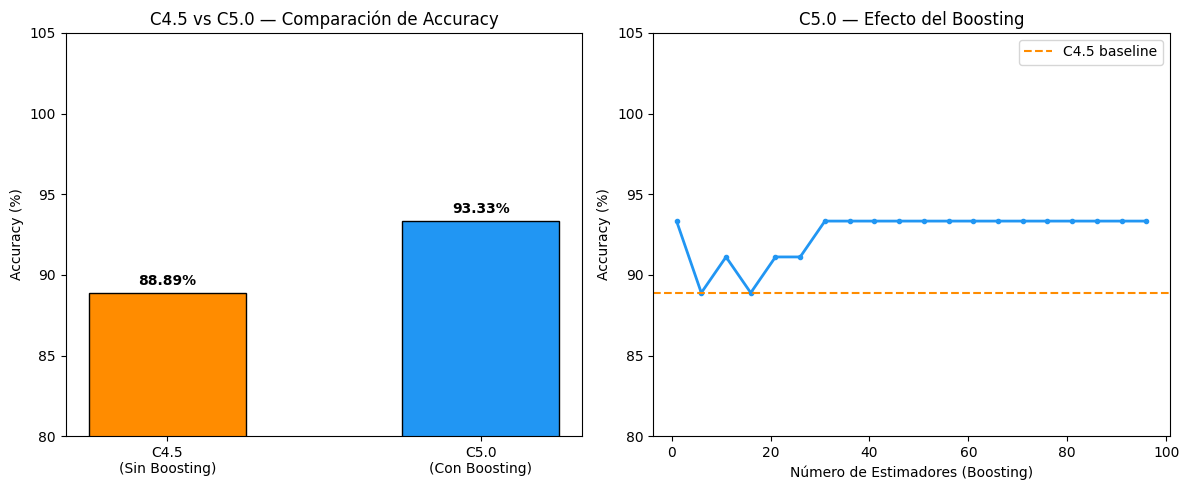


 C5.0 mejora la precisión de C4.5 gracias al Boosting


In [19]:
# ============================================================
# Comparación visual C4.5 vs C5.0
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos   = ['C4.5\n(Sin Boosting)', 'C5.0\n(Con Boosting)']
accuracys = [acc_c45 * 100, acc_c50 * 100]
colores   = ['#FF8C00', '#2196F3']

# Gráfico de barras
bars = axes[0].bar(modelos, accuracys, color=colores, edgecolor='black', width=0.5)
axes[0].set_ylim(80, 105)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('C4.5 vs C5.0 — Comparación de Accuracy')
for bar, val in zip(bars, accuracys):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', fontweight='bold')

# Gráfico de accuracy por número de estimadores en C5.0
n_estimadores = range(1, 101, 5)
accs = []
for n in n_estimadores:
    m = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(criterion='entropy', max_depth=3),
        n_estimators=n, random_state=42
    )
    m.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test)) * 100)

axes[1].plot(list(n_estimadores), accs, color='#2196F3', linewidth=2, marker='o', markersize=3)
axes[1].axhline(acc_c45 * 100, color='#FF8C00', linestyle='--', label='C4.5 baseline')
axes[1].set_xlabel('Número de Estimadores (Boosting)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('C5.0 — Efecto del Boosting')
axes[1].legend()
axes[1].set_ylim(80, 105)

plt.tight_layout()
plt.show()
print('\n C5.0 mejora la precisión de C4.5 gracias al Boosting')

In [20]:
# ============================================================
# Reporte detallado C5.0
# ============================================================
print(' Reporte de Clasificación — C5.0 (con Boosting):')
print(classification_report(
    y_test,
    c50.predict(X_test),
    target_names=iris.target_names
))

 Reporte de Clasificación — C5.0 (con Boosting):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



## 10. Conclusiones

- **C4.5** es un algoritmo robusto y ampliamente utilizado para clasificación, siendo una evolución directa de ID3.
- Su uso del **Ratio de Ganancia** lo hace más justo al seleccionar atributos con muchos valores únicos.
- La capacidad de manejar **valores continuos y datos faltantes** lo hace muy versátil en la práctica.
- **C5.0** mejora la eficiencia computacional y agrega soporte para boosting, siendo superior en datasets grandes.
- En `scikit-learn`, `DecisionTreeClassifier(criterion='entropy')` es la implementación más cercana a C4.5 disponible en Python.

---
*Tarea 1 — Investigación en Grupo | Algoritmos de ML | Docente: Jheser Guzman (@Bluminds)*